This code is an example of statlab's ordinal classification tools, as posted in Zenodo: https://doi.org/10.5281/zenodo.18990526, which was used to generate the results in the manuscript "Classifier Pooling for Modern Ordinal Classification" https://arxiv.org/abs/2603.17278

In [1]:
import statlab.ord

import numpy as np
import copy

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sn

import sklearn.model_selection
import sklearn.linear_model
import sklearn.naive_bayes
import sklearn.svm
import sklearn.ensemble


import statsmodels.miscmodels.ordinal_model

import RyStats.common

from ucimlrepo import fetch_ucirepo

import medmnist
import radiomics
import radiomics.featureextractor
import SimpleITK as sitk

!pip freeze

absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.3
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.12.1
anywidget==0.9.21
apsw==3.51.2.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.3.2.0.47.4
astunparse==1.6.3
atpublic==5.1
attrs==25.4.0
audioread==3.1.0
Authlib==1.6.9
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.37.0
bigquery-magics==0.10.3
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.1.2
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
certifi==2026.2.25
cff

## Evaluation

### Evaluation scripts

In [2]:
def tune_and_test_ordinal_classifier(distr, data=None, scale_x=False, plot=False):

    df_trainX, df_trainY, df_valX, df_valY = data

    if scale_x:
        scaler = sklearn.preprocessing.StandardScaler()
        df_trainX = scaler.fit_transform(df_trainX)
        df_valX = scaler.transform(df_valX)


    model = statsmodels.miscmodels.ordinal_model.OrderedModel(df_trainY, df_trainX, distr=distr)

    res_log = model.fit(method='bfgs')
    print("Model summary:")
    print(res_log.summary())

    print("train accuracy:", np.mean(df_trainY == res_log.model.predict(res_log.params, exog=df_trainX).argmax(1)))

    print("MAIN METRICS:")
    train_predictions = res_log.model.predict(res_log.params, exog=df_trainX).argmax(1) + np.min(df_trainY)
    val_predictions = res_log.model.predict(res_log.params, exog=df_valX).argmax(1) + np.min(df_valY)
    print("val accuracy:", np.mean(df_valY == val_predictions))
    val_WA = np.mean([np.mean(df_valY[df_valY==class_i] == val_predictions[df_valY==class_i]) for class_i in df_trainY.unique()])
    print("val accuracy (weighted):", val_WA)
    val_PC = polycor_RyStats(df_valY, val_predictions)
    print("val polychoric correlation (RyStats):", val_PC)
    val_AUC = sklearn.metrics.roc_auc_score(df_valY, res_log.model.predict(res_log.params, exog=df_valX), multi_class='ovr')
    print("val OVR AUC:", val_AUC) # CURRENTLY MACRO AVERAGING
    print("\n")

    if plot:

        plt.title(f"Training Confusion matrix")
        sn.heatmap(sklearn.metrics.confusion_matrix(df_trainY, train_predictions, normalize='true'), annot=True,
                   xticklabels=np.sort(df_trainY.unique()), yticklabels=np.sort(df_trainY.unique()))
        plt.xlabel(f"Predicted")
        plt.ylabel(f"Actual")
        plt.show()


        plt.title(f"Validation Confusion matrix")
        sn.heatmap(sklearn.metrics.confusion_matrix(df_valY, val_predictions, normalize='true'), annot=True,
                   xticklabels=np.sort(df_valY.unique()), yticklabels=np.sort(df_valY.unique()))
        plt.xlabel(f"Predicted")
        plt.ylabel(f"Actual")
        plt.show()

        plt.scatter(val_predictions, df_valY)
        plt.xlabel("val predictions"); plt.ylabel("val true")
        plt.show()
        plt.scatter(df_valY, val_predictions)
        plt.xlabel("val true"); plt.ylabel("val predictions")
        plt.show()

    return [val_WA, val_PC, val_AUC]



In [3]:
def ordinal_classification_test_pipeline(df_trainX1, df_trainY1, df_valX1, df_valY1, best_split_threshold='best_clf', train_native_clf=True, plot=False):
    # the Y classes should be 0-based and step of 1 (i.e. 0, 1, ... n)

    print(f"num training samples: {len(df_trainX1)}; num val samples: {len(df_valX1)}")
    results = pd.DataFrame(index=["AW", "PC", "OVR AUC"])

    if best_split_threshold == 'best_clf':
        try:
            print("ordered LOGIT MODEL:")
            results["ordered logit"] = tune_and_test_ordinal_classifier("logit", data=(df_trainX1, df_trainY1, df_valX1, df_valY1), plot=plot)
        except:
            print("ordinal logit model failed")
        try:
            print("ordered PROBIT MODEL:")
            probit_results = tune_and_test_ordinal_classifier("probit", data=(df_trainX1, df_trainY1, df_valX1, df_valY1), plot=plot)
        except:
            print("ordinal probit model failed")



    for classifier, clf_name in zip([sklearn.linear_model.LogisticRegression(max_iter=1000), sklearn.naive_bayes.GaussianNB(), sklearn.svm.SVC(probability=True), sklearn.ensemble.GradientBoostingClassifier(),],
                                    ["Logistic", "GaussNB", "SVC", "XGB"]):
        for method, prediction_paradigm in zip([classifier, statlab.ord.SubtractionOrdinalClassifier(classifier), statlab.ord.TreeOrdinalClassifier(classifier)],
                                              ["native", "cumulative", "tree-based"]):
            print(classifier, prediction_paradigm, ':')
            if (prediction_paradigm == "cumulative") or (prediction_paradigm == "tree-based"):
                method = method.fit(df_trainX1, df_trainY1, best_split_threshold=best_split_threshold)
            elif train_native_clf:
                method.fit(df_trainX1, df_trainY1)
            else:
                continue


            val_predict_probas = method.predict_proba(df_valX1)
            train_predictions = method.predict(df_trainX1)
            val_predictions = method.predict(df_valX1)
            print(df_valX1.shape, val_predict_probas.shape, val_predictions.shape)

            print("MAIN METRICS:")
            print("val accuracy:", np.mean(df_valY1 == val_predictions))
            val_AW = np.mean([np.mean(df_valY1[df_valY1==class_i] == val_predictions[df_valY1==class_i]) for class_i in df_trainY1.unique()])
            print("val accuracy (weighted):", val_AW)
            val_OVR_AUC = sklearn.metrics.roc_auc_score(df_valY1, val_predict_probas, multi_class='ovr')
            print("val OVR AUC:", val_OVR_AUC) # MACRO AVERAGING
            val_PC = polycor_RyStats(df_valY1, val_predictions)
            print("val polychoric correlation (RyStats):", val_PC)
            results[clf_name + " " + prediction_paradigm] = [val_AW, val_PC, val_OVR_AUC]

            if plot:
                plt.title(f"Training Confusion matrix")
                sn.heatmap(sklearn.metrics.confusion_matrix(df_trainY1, np.round(train_predictions.squeeze()), normalize='true'), annot=True,
                       xticklabels=np.sort(df_trainY1.unique()), yticklabels=np.sort(df_trainY1.unique()))
                plt.xlabel(f"Predicted")
                plt.ylabel(f"Actual")
                plt.show()

                plt.title(f"Validation Confusion matrix")
                sn.heatmap(sklearn.metrics.confusion_matrix(df_valY1, np.round(val_predictions.squeeze()), normalize='true'), annot=True,
                       xticklabels=np.sort(df_valY1.unique()), yticklabels=np.sort(df_valY1.unique()))
                plt.xlabel(f"Predicted")
                plt.ylabel(f"Actual")
                plt.show()

        if (best_split_threshold == 'best_clf') and (clf_name == "Logistic"):
            # make the probit results show below Logistic
            results["ordered probit"] = probit_results


    print(results.T)
    return results.T


def polycor_RyStats(vec1, vec2, min=0, max=10):
    return RyStats.common.polychoric_correlation(np.asarray([vec1, vec2]), min, max)[0][1]

### Evaluation on datasets

#### UCI Car dataset

In [4]:
# UCI car dataset

# fetch dataset
car_evaluation = fetch_ucirepo(id=19)

# data (as pandas dataframes)
df_carX = copy.deepcopy(car_evaluation.data.features)
df_carY = copy.deepcopy(car_evaluation.data.targets)

# metadata
print(car_evaluation.metadata)

# variable information
print(car_evaluation.variables)

{'uci_id': 19, 'name': 'Car Evaluation', 'repository_url': 'https://archive.ics.uci.edu/dataset/19/car+evaluation', 'data_url': 'https://archive.ics.uci.edu/static/public/19/data.csv', 'abstract': 'Derived from simple hierarchical decision model, this database may be useful for testing constructive induction and structure discovery methods.', 'area': 'Other', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1728, 'num_features': 6, 'feature_types': ['Categorical'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1988, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5JP48', 'creators': ['Marko Bohanec'], 'intro_paper': {'ID': 249, 'type': 'NATIVE', 'title': 'Knowledge acquisition and explanation for multi-attribute decision making', 'authors': 'M. Bohanec, V. Rajkovič', 'venue': '8th Intl Workshop on Expert Systems and their Applications, 

In [5]:
df_carX['buying'] = df_carX['buying'].map({'low': 1, 'med': 2, 'high': 3, 'vhigh': 4})
df_carX['maint'] =   df_carX['maint'].map({'low': 1, 'med': 2, 'high': 3, 'vhigh': 4})
df_carX['doors'] = df_carX['doors'].map({'2': 2, '3': 3, '4': 4, '5more': 5})

df_carX['persons'] = df_carX['persons'].map({'2': 2, '4': 4, 'more': 5})
df_carX['lug_boot'] = df_carX['lug_boot'].map({'small': 1, 'med': 2, 'big': 3})
df_carX['safety'] = df_carX['safety'].map({'low': 1, 'med': 2, 'high': 3})

df_carY = df_carY['class'].map({'unacc': 0, 'acc': 1, 'good': 2, 'vgood': 3})

df_carY

,class
0,0
1,0
2,0
3,0
4,0
...,...
1723,2
1724,3
1725,0
1726,2


In [6]:
df_car_trainX, df_car_valX, df_car_trainY, df_car_valY = sklearn.model_selection.train_test_split(df_carX, df_carY, test_size=0.3, stratify=df_carY, random_state=0)

ordinal_classification_test_pipeline(df_car_trainX, df_car_trainY, df_car_valX, df_car_valY)


num training samples: 1209; num val samples: 519
ordered LOGIT MODEL:
Optimization terminated successfully.
         Current function value: 0.388615
         Iterations: 39
         Function evaluations: 41
         Gradient evaluations: 41
Model summary:
                             OrderedModel Results                             
Dep. Variable:                  class   Log-Likelihood:                -469.84
Model:                   OrderedModel   AIC:                             957.7
Method:            Maximum Likelihood   BIC:                             1004.
Date:                Wed, 11 Mar 2026                                         
Time:                        18:39:35                                         
No. Observations:                1209                                         
Df Residuals:                    1200                                         
Df Model:                           6                                         
                 coef    std err

,AW,PC,OVR AUC
ordered logit,0.606648,0.908526,0.945289
Logistic native,0.657387,0.899416,0.963003
Logistic cumulative,0.686434,0.907085,0.965934
Logistic tree-based,0.662231,0.913396,0.963507
ordered probit,0.586296,0.909718,0.945213
GaussNB native,0.622048,0.893851,0.932040
GaussNB cumulative,0.753545,0.959366,0.871179
GaussNB tree-based,0.708395,0.942283,0.962013
SVC native,0.811617,0.974821,0.995410
SVC cumulative,0.929920,0.982566,0.993234


#### Fetal Health dataset

In [7]:
df_fetal = pd.read_csv('/content/fetal_health.csv') # fetal_health.csv from https://www.kaggle.com/datasets/andrewmvd/fetal-health-classification/data
df_fetal.describe()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,...,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,0.003178,0.009481,0.004366,0.001889,0.000003,0.000159,46.990122,1.332785,9.84666,...,93.579492,164.025400,4.068203,0.323612,137.452023,134.610536,138.090310,18.808090,0.320320,1.304327
std,9.840844,0.003866,0.046666,0.002946,0.002960,0.000057,0.000590,17.192814,0.883241,18.39688,...,29.560212,17.944183,2.949386,0.706059,16.381289,15.593596,14.466589,28.977636,0.610829,0.614377
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,...,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.00000,...,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,0.002000,0.000000,0.004000,0.000000,0.000000,0.000000,49.000000,1.200000,0.00000,...,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.00000,...,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.00000,...,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000


In [8]:
df_fetal_trainX, df_fetal_valX, df_fetal_trainY, df_fetal_valY = sklearn.model_selection.train_test_split(df_fetal.iloc[:,:-1], df_fetal.iloc[:,-1], test_size=0.3, stratify=df_fetal['fetal_health'], random_state=0)

ordinal_classification_test_pipeline(df_fetal_trainX, df_fetal_trainY, df_fetal_valX, df_fetal_valY)

num training samples: 1488; num val samples: 638
ordered LOGIT MODEL:
Optimization terminated successfully.
         Current function value: 0.294692
         Iterations: 199
         Function evaluations: 204
         Gradient evaluations: 204
Model summary:
                             OrderedModel Results                             
Dep. Variable:           fetal_health   Log-Likelihood:                -438.50
Model:                   OrderedModel   AIC:                             923.0
Method:            Maximum Likelihood   BIC:                             1045.
Date:                Wed, 11 Mar 2026                                         
Time:                        18:40:12                                         
No. Observations:                1488                                         
Df Residuals:                    1465                                         
Df Model:                          21                                         
                             

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


val polychoric correlation (RyStats): 0.9109437277756418
val OVR AUC: 0.9473480710246216


ordered PROBIT MODEL:
Optimization terminated successfully.
         Current function value: 0.295363
         Iterations: 178
         Function evaluations: 182
         Gradient evaluations: 182
Model summary:
                             OrderedModel Results                             
Dep. Variable:           fetal_health   Log-Likelihood:                -439.50
Model:                   OrderedModel   AIC:                             925.0
Method:            Maximum Likelihood   BIC:                             1047.
Date:                Wed, 11 Mar 2026                                         
Time:                        18:40:17                                         
No. Observations:                1488                                         
Df Residuals:                    1465                                         
Df Model:                          21                            

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


val polychoric correlation (RyStats): 0.9143310712391135
LogisticRegression(max_iter=1000) cumulative :


...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

updated val_classifier_performances (fold 2): [2.20205525 2.40710383]
updated val_classifier_performances (fold 3): [2.88736993 3.11080753]
best_clf ind: 1
Chosen best_split_ind: 1
(638, 21) (638, 3) (638,)
MAIN METRICS:
val accuracy: 0.8730407523510971
val accuracy (weighted): 0.7629146807661291
val OVR AUC: 0.9350992210825678


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

val polychoric correlation (RyStats): 0.9120446382983771
GaussianNB() native :
(638, 21) (638, 3) (638,)
MAIN METRICS:
val accuracy: 0.8009404388714734
val accuracy (weighted): 0.7619264759511903
val OVR AUC: 0.899861861231669
val polychoric correlation (RyStats): 0.8306463469589112
GaussianNB() cumulative :
updated val_classifier_performances (fold 0): [0.74576271 0.72972973]
updated val_classifier_performances (fold 1): [1.49576271 1.3963964 ]
updated val_classifier_performances (fold 2): [2.2485717  2.04345522]
updated val_classifier_performances (fold 3): [2.98931244 2.61102279]
best_clf ind: 0
Chosen best_split_ind: 0
(638, 21) (638, 3) (638,)
MAIN METRICS:
val accuracy: 0.8589341692789969
val accuracy (weighted): 0.7749658327322425
val OVR AUC: 0.9325307300784486
val polychoric correlation (RyStats): 0.8785299520428258
GaussianNB() tree-based :
updated val_classifier_performances (fold 0): [0.74576271 0.72972973]
updated val_classifier_performances (fold 1): [1.49576271 1.3963964

,AW,PC,OVR AUC
ordered logit,0.697630,0.910944,0.947348
Logistic native,0.743832,0.914331,0.925106
Logistic cumulative,0.756625,0.906358,0.935754
Logistic tree-based,0.762915,0.912045,0.935099
ordered probit,0.702089,0.913802,0.946794
GaussNB native,0.761926,0.830646,0.899862
GaussNB cumulative,0.774966,0.878530,0.932531
GaussNB tree-based,0.774966,0.878530,0.934236
SVC native,0.612466,0.845298,0.930576
SVC cumulative,0.715899,0.873572,0.930895


#### UCI wine tasting dataset

In [9]:
# UCI wine tasting dataset

# fetch dataset
wine_evaluation = fetch_ucirepo(id=109)

# data (as pandas dataframes)
df_wineX = copy.deepcopy(wine_evaluation.data.features)
df_wineY = copy.deepcopy(wine_evaluation.data.targets['class']) # - 1

# metadata
print(wine_evaluation.metadata)

# variable information
print(wine_evaluation.variables)

np.unique(df_wineY)

{'uci_id': 109, 'name': 'Wine', 'repository_url': 'https://archive.ics.uci.edu/dataset/109/wine', 'data_url': 'https://archive.ics.uci.edu/static/public/109/data.csv', 'abstract': 'Using chemical analysis to determine the origin of wines', 'area': 'Physics and Chemistry', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 178, 'num_features': 13, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1992, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C5PC7J', 'creators': ['Stefan Aeberhard', 'M. Forina'], 'intro_paper': {'ID': 246, 'type': 'NATIVE', 'title': 'Comparative analysis of statistical pattern recognition methods in high dimensional settings', 'authors': 'S. Aeberhard, D. Coomans, O. Vel', 'venue': 'Pattern Recognition', 'year': 1994, 'journal': None, 'DOI': '10.1016/0031-3203(94)90145-7', 'URL': 'https:

array([1, 2, 3])

In [10]:
df_wine_trainX, df_wine_valX, df_wine_trainY, df_wine_valY = sklearn.model_selection.train_test_split(df_wineX, df_wineY, test_size=0.3, stratify=df_wineY, random_state=0)

ordinal_classification_test_pipeline(df_wine_trainX, df_wine_trainY, df_wine_valX, df_wine_valY)

num training samples: 124; num val samples: 54
ordered LOGIT MODEL:
Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 472
         Function evaluations: 498
         Gradient evaluations: 498
Model summary:
                             OrderedModel Results                             
Dep. Variable:                  class   Log-Likelihood:            -3.3940e-06
Model:                   OrderedModel   AIC:                             30.00
Method:            Maximum Likelihood   BIC:                             72.30
Date:                Wed, 11 Mar 2026                                         
Time:                        18:40:43                                         
No. Observations:                 124                                         
Df Residuals:                     109                                         
Df Model:                          13                                         
                               

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


val polychoric correlation (RyStats): 0.9989959874894344
val OVR AUC: 0.9285353535353537


ordered PROBIT MODEL:
Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 361
         Function evaluations: 376
         Gradient evaluations: 376
Model summary:
                             OrderedModel Results                             
Dep. Variable:                  class   Log-Likelihood:            -2.4483e-05
Model:                   OrderedModel   AIC:                             30.00
Method:            Maximum Likelihood   BIC:                             72.30
Date:                Wed, 11 Mar 2026                                         
Time:                        18:40:47                                         
No. Observations:                 124                                         
Df Residuals:                     109                                         
Df Model:                          13                            

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


val polychoric correlation (RyStats): 0.9989959874894344
val OVR AUC: 0.929978354978355


LogisticRegression(max_iter=1000) native :
(54, 13) (54, 3) (54,)
MAIN METRICS:
val accuracy: 0.9629629629629629
val accuracy (weighted): 0.9682539682539683
val OVR AUC: 0.9980425952648174


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


val polychoric correlation (RyStats): 0.9989959874894344
LogisticRegression(max_iter=1000) cumulative :
updated val_classifier_performances (fold 0): [0.95454545 0.94117647]
updated val_classifier_performances (fold 1): [1.95454545 1.94117647]
updated val_classifier_performances (fold 2): [2.93015521 2.81617647]
updated val_classifier_performances (fold 3): [3.9068994  3.75735294]
best_clf ind: 0
Chosen best_split_ind: 0
(54, 13) (54, 3) (54,)
MAIN METRICS:
val accuracy: 0.9814814814814815
val accuracy (weighted): 0.9841269841269842
val OVR AUC: 0.9975281919726364
val polychoric correlation (RyStats): 0.9989959874894344
LogisticRegression(max_iter=1000) tree-based :
updated val_classifier_performances (fold 0): [0.95454545 0.94117647]
updated val_classifier_performances (fold 1): [1.95454545 1.94117647]
updated val_classifier_performances (fold 2): [2.93015521 2.81617647]
updated val_classifier_performances (fold 3): [3.9068994  3.75735294]
best_clf ind: 0
Chosen best_split_ind: 0
(54,

,AW,PC,OVR AUC
ordered logit,0.907937,0.998996,0.928535
Logistic native,0.968254,0.998996,0.998043
Logistic cumulative,0.984127,0.998996,0.997528
Logistic tree-based,0.984127,0.998996,0.997047
ordered probit,0.907937,0.998996,0.929978
GaussNB native,0.965608,0.998996,0.999519
GaussNB cumulative,0.965608,0.998996,0.998043
GaussNB tree-based,0.965608,0.998996,0.998043
SVC native,0.605291,0.445718,0.865799
SVC cumulative,0.667725,0.637398,0.892224


#### UCI Abalone age dataset

{'uci_id': 1, 'name': 'Abalone', 'repository_url': 'https://archive.ics.uci.edu/dataset/1/abalone', 'data_url': 'https://archive.ics.uci.edu/static/public/1/data.csv', 'abstract': 'Predict the age of abalone from physical measurements', 'area': 'Biology', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Tabular'], 'num_instances': 4177, 'num_features': 8, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': [], 'target_col': ['Rings'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1994, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C55C7W', 'creators': ['Warwick Nash', 'Tracy Sellers', 'Simon Talbot', 'Andrew Cawthorn', 'Wes Ford'], 'intro_paper': None, 'additional_info': {'summary': 'Predicting the age of abalone from physical measurements.  The age of abalone is determined by cutting the shell through the cone, staining it, and counting the number of rings through a microscope -- 

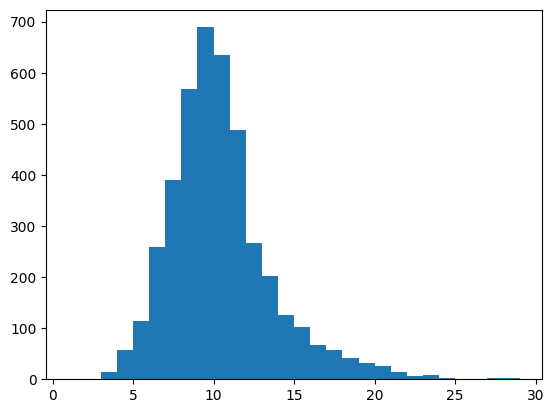

age 1: 1
age 2: 1
age 3: 15
age 4: 57
age 5: 115
age 6: 259
age 7: 391
age 8: 568
age 9: 689
age 10: 634
age 11: 487
age 12: 267
age 13: 203
age 14: 126
age 15: 103
age 16: 67
age 17: 58
age 18: 42
age 19: 32
age 20: 26
age 21: 14
age 22: 6
age 23: 9
age 24: 2
age 25: 1
age 26: 1
age 27: 2
age 29: 1


In [11]:
# UCI Abalone age dataset

# fetch dataset
abalone_age_ds = fetch_ucirepo(id=1)

# data (as pandas dataframes)
df_abaloneX = copy.deepcopy(abalone_age_ds.data.features)
df_abaloneYraw = copy.deepcopy(abalone_age_ds.data.targets['Rings'])

# metadata
print(abalone_age_ds.metadata)

# variable information
print(abalone_age_ds.variables)

plt.hist(abalone_age_ds.data.targets, bins=np.unique(abalone_age_ds.data.targets))
plt.show()

for i in np.unique(df_abaloneYraw):
    print(f"age {i}: {np.sum(df_abaloneYraw==i)}")


df_abaloneX['Sex'] = df_abaloneX['Sex'].map({'M': 1, 'I': 2, 'F': 3})

In [12]:
# experiment 2 on Abalone age

def abalone_transform_3classes(raw):
    if   raw < 10: return 0
    elif raw < 12: return 1
    else:          return 2

def abalone_transform_7classes(raw):
    if   raw < 5:  return 0
    elif raw < 8:  return 1
    elif raw < 11: return 2
    elif raw < 13: return 3
    elif raw < 15: return 4
    elif raw < 18: return 5
    else:          return 6


abalone_results_exp2 = {}
import sklearn.preprocessing
for ds_size in ['full', 'small']:
    for num_classes in [3, 7]:
        print(f"[begin results for ds_size {ds_size}, num_classes {num_classes}]")

        if ds_size == 'full':
            train_fraction = 1.0
        elif ds_size == 'small':
            train_fraction = 0.5
        else:
            raise Exception("ds_size must be 'small' or 'full'")

        if num_classes == 3:
            df_abaloneY = df_abaloneYraw.apply(abalone_transform_3classes)
        elif num_classes == 7:
            df_abaloneY = df_abaloneYraw.apply(abalone_transform_7classes)
        else:
            raise Exception("num_classes must be 3 or 7")


        df_abalone_trainX, df_abalone_testX, df_abalone_trainY, df_abalone_testY = sklearn.model_selection.train_test_split(df_abaloneX, df_abaloneY, test_size=0.3, stratify=df_abaloneY, random_state=0)
        if train_fraction < 0.9999:
            # update the training sets but keep the same test sets
            df_abalone_trainX,  _,  df_abalone_trainY,  _  = sklearn.model_selection.train_test_split(df_abalone_trainX, df_abalone_trainY, train_size=train_fraction, stratify=df_abalone_trainY, random_state=0)

        abalone_results_exp2[f"ds_size {ds_size}, num_classes {num_classes}"] = ordinal_classification_test_pipeline(df_abalone_trainX, df_abalone_trainY, df_abalone_testX, df_abalone_testY)
        print(f"[end results for ds_size {ds_size}, num_classes {num_classes}]")



[begin results for ds_size full, num_classes 3]
num training samples: 2923; num val samples: 1254
ordered LOGIT MODEL:
Optimization terminated successfully.
         Current function value: 0.766853
         Iterations: 110
         Function evaluations: 113
         Gradient evaluations: 113
Model summary:
                             OrderedModel Results                             
Dep. Variable:                  Rings   Log-Likelihood:                -2241.5
Model:                   OrderedModel   AIC:                             4503.
Method:            Maximum Likelihood   BIC:                             4563.
Date:                Wed, 11 Mar 2026                                         
Time:                        18:40:56                                         
No. Observations:                2923                                         
Df Residuals:                    2913                                         
Df Model:                           8                      

In [13]:
abalone_results_exp2["ds_size full, num_classes 3"]

,AW,PC,OVR AUC
ordered logit,0.570588,0.724250,0.797847
Logistic native,0.594180,0.720688,0.811513
Logistic cumulative,0.582755,0.710795,0.806311
Logistic tree-based,0.561218,0.692217,0.801709
ordered probit,0.567801,0.727094,0.797356
GaussNB native,0.505826,0.578261,0.739025
GaussNB cumulative,0.482527,0.558961,0.709764
GaussNB tree-based,0.479566,0.559241,0.706408
SVC native,0.564982,0.680083,0.815787
SVC cumulative,0.592407,0.693817,0.809352


In [14]:
abalone_results_exp2["ds_size full, num_classes 7"]

,AW,PC,OVR AUC
ordered logit,0.296361,0.762813,0.833014
Logistic native,0.241333,0.704150,0.844607
Logistic cumulative,0.258923,0.715126,0.843729
Logistic tree-based,0.268926,0.723181,0.841001
ordered probit,0.258833,0.749800,0.830974
GaussNB native,0.404198,0.646359,0.764400
GaussNB cumulative,0.394247,0.653556,0.721972
GaussNB tree-based,0.383214,0.646334,0.733780
SVC native,0.242196,0.742414,0.856976
SVC cumulative,0.350702,0.763752,0.826056


In [15]:
abalone_results_exp2["ds_size small, num_classes 3"]

,AW,PC,OVR AUC
ordered logit,0.575535,0.737448,0.797454
Logistic native,0.590222,0.712369,0.803072
Logistic cumulative,0.561081,0.666749,0.796076
Logistic tree-based,0.533221,0.669048,0.790041
ordered probit,0.566380,0.734619,0.797341
GaussNB native,0.495352,0.565409,0.740176
GaussNB cumulative,0.481854,0.559720,0.710135
GaussNB tree-based,0.485597,0.561720,0.708361
SVC native,0.503236,0.613515,0.799362
SVC cumulative,0.572487,0.657140,0.797141


In [16]:
abalone_results_exp2["ds_size small, num_classes 7"]

,AW,PC,OVR AUC
ordered logit,0.298610,0.749335,0.830898
Logistic native,0.236291,0.695073,0.836552
Logistic cumulative,0.260770,0.701058,0.832864
Logistic tree-based,0.259608,0.707334,0.829346
ordered probit,0.256360,0.739549,0.828572
GaussNB native,0.423605,0.652524,0.767571
GaussNB cumulative,0.398342,0.656482,0.724969
GaussNB tree-based,0.382858,0.648071,0.734880
SVC native,0.236037,0.716585,0.855385
SVC cumulative,0.366745,0.732686,0.817068


In [17]:
abalone_results_exp2["ds_size small, num_classes 7"] - abalone_results_exp2["ds_size full, num_classes 3"]

,AW,PC,OVR AUC
ordered logit,-0.271978,0.025085,0.033051
Logistic native,-0.357889,-0.025615,0.025039
Logistic cumulative,-0.321985,-0.009737,0.026553
Logistic tree-based,-0.301610,0.015116,0.027636
ordered probit,-0.311442,0.012455,0.031216
GaussNB native,-0.082221,0.074263,0.028545
GaussNB cumulative,-0.084185,0.097521,0.015205
GaussNB tree-based,-0.096708,0.088830,0.028472
SVC native,-0.328945,0.036502,0.039598
SVC cumulative,-0.225661,0.038869,0.007716


In [18]:
# experiment 3 on Abalone age, 8 classes
abalone_results_exp3 = {}
def abalone_transform_8classes_spreadOutIndices(raw):
    if   raw < 5:  return 0
    elif raw < 7:  return 1
    elif raw < 8:  return 2
    elif raw < 9:  return 3
    elif raw < 10: return 4
    elif raw < 12: return 5
    elif raw < 15: return 6
    else:          return 7

df_abaloneY = df_abaloneYraw.apply(abalone_transform_8classes_spreadOutIndices)
for best_split_threshold_method in ['even_split', 'best_clf', 'last_split', 'middle']:
    print(f"#### begin results for best_split_threshold_method: {best_split_threshold_method}")

    df_abalone_trainX, df_abalone_testX, df_abalone_trainY, df_abalone_testY = sklearn.model_selection.train_test_split(df_abaloneX, df_abaloneY, test_size=0.3, stratify=df_abaloneY, random_state=0)

    abalone_results_exp3[best_split_threshold_method] = ordinal_classification_test_pipeline(df_abalone_trainX, df_abalone_trainY, df_abalone_testX, df_abalone_testY, best_split_threshold=best_split_threshold_method, train_native_clf=False)
    print(f"end results for best_split_threshold_method: {best_split_threshold_method}")



#### begin results for best_split_threshold_method: even_split
num training samples: 2923; num val samples: 1254
LogisticRegression(max_iter=1000) native :
LogisticRegression(max_iter=1000) cumulative :
Chosen best_split_ind: 4
(1254, 8) (1254, 8) (1254,)
MAIN METRICS:
val accuracy: 0.3883572567783094
val accuracy (weighted): 0.3096420003415615
val OVR AUC: 0.8243250697025477
val polychoric correlation (RyStats): 0.7669351314352486
LogisticRegression(max_iter=1000) tree-based :
Chosen best_split_ind: 4
(1254, 8) (1254, 8) (1254,)
MAIN METRICS:
val accuracy: 0.35566188197767146
val accuracy (weighted): 0.26801783976456894
val OVR AUC: 0.8132575705448026
val polychoric correlation (RyStats): 0.7635855990043782
GaussianNB() native :
GaussianNB() cumulative :
Chosen best_split_ind: 4
(1254, 8) (1254, 8) (1254,)
MAIN METRICS:
val accuracy: 0.22089314194577353
val accuracy (weighted): 0.34588722013330864
val OVR AUC: 0.7313809973374221
val polychoric correlation (RyStats): 0.6891059238724933

In [19]:
abalone_results_exp3["even_split"]

,AW,PC,OVR AUC
Logistic cumulative,0.309642,0.766935,0.824325
Logistic tree-based,0.268018,0.763586,0.813258
GaussNB cumulative,0.345887,0.689106,0.731381
GaussNB tree-based,0.342188,0.684340,0.739746
SVC cumulative,0.359133,0.761789,0.808397
SVC tree-based,0.335574,0.757090,0.820336
XGB cumulative,0.375967,0.772259,0.820241
XGB tree-based,0.366227,0.794372,0.833313


In [20]:
abalone_results_exp3["best_clf"]

,AW,PC,OVR AUC
ordered logit,0.328829,0.775770,0.811320
Logistic cumulative,0.309642,0.766935,0.824325
Logistic tree-based,0.306915,0.745815,0.815431
ordered probit,0.306186,0.771689,0.809127
GaussNB cumulative,0.345887,0.689106,0.731387
GaussNB tree-based,0.342421,0.684725,0.736495
SVC cumulative,0.362596,0.762735,0.809003
SVC tree-based,0.353354,0.760234,0.818112
XGB cumulative,0.380681,0.770262,0.818575
XGB tree-based,0.380123,0.782902,0.830399


In [21]:
abalone_results_exp3["last_split"]

,AW,PC,OVR AUC
Logistic cumulative,0.309642,0.766935,0.824325
Logistic tree-based,0.269357,0.781943,0.815664
GaussNB cumulative,0.345887,0.689106,0.731348
GaussNB tree-based,0.342237,0.683316,0.734458
SVC cumulative,0.357250,0.759351,0.805126
SVC tree-based,0.343678,0.773758,0.813110
XGB cumulative,0.378169,0.762314,0.817318
XGB tree-based,0.368970,0.781194,0.833027


In [22]:
abalone_results_exp3["middle"]

,AW,PC,OVR AUC
Logistic cumulative,0.309642,0.766935,0.824325
Logistic tree-based,0.284806,0.746649,0.813568
GaussNB cumulative,0.345887,0.689106,0.731381
GaussNB tree-based,0.342421,0.684882,0.741425
SVC cumulative,0.371216,0.764102,0.809811
SVC tree-based,0.339123,0.758771,0.819020
XGB cumulative,0.380957,0.774447,0.819973
XGB tree-based,0.372679,0.794562,0.833516


#### retina medMNIST

Example images:
grade: [0]


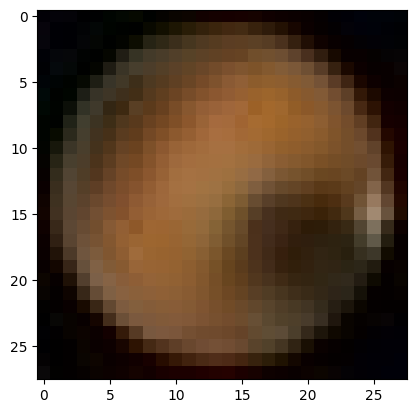

grade: [0]


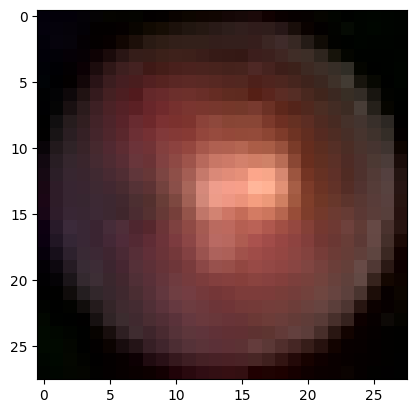

grade: [0]


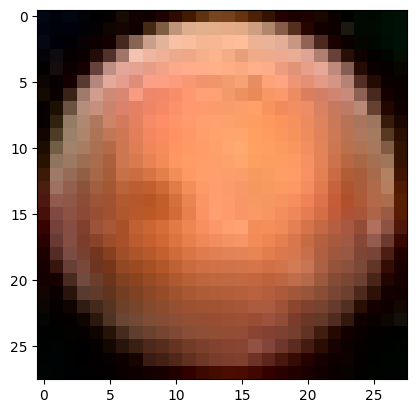

grade: [4]


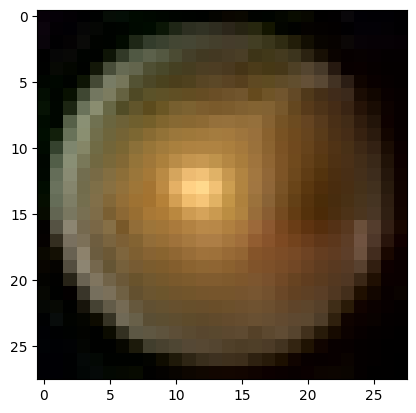

grade: [3]


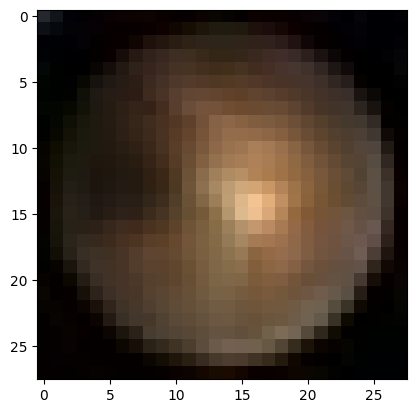

grade: [0]


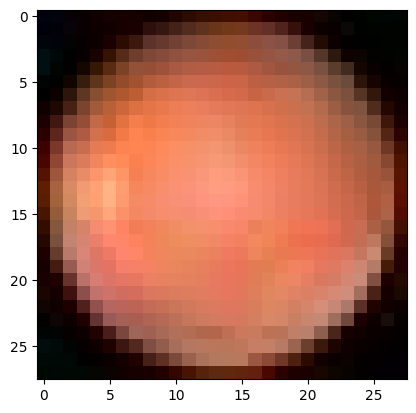

grade: [4]


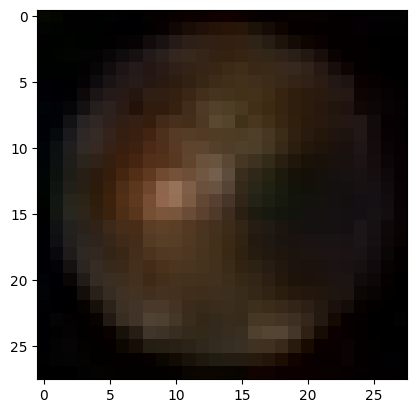

grade: [0]


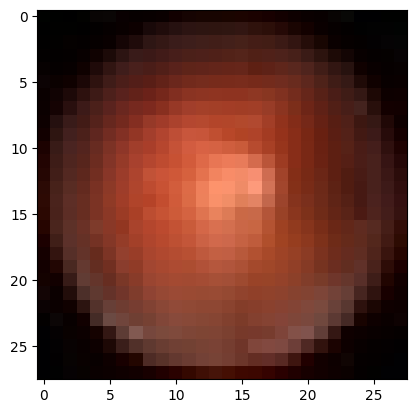

grade: [3]


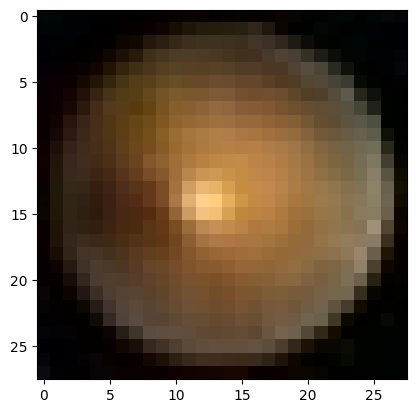

grade: [2]


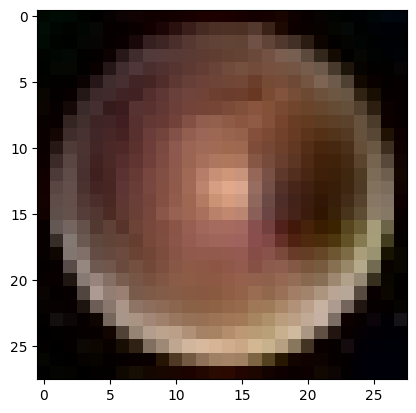

In [23]:
retinamnist_trainset = medmnist.RetinaMNIST('train', download=True)
retinamnist_testset  = medmnist.RetinaMNIST('test', download=True)


print("Example images:")
for i in range(10):
    print("grade:", retinamnist_trainset.labels[i])
    plt.imshow(retinamnist_trainset.imgs[i])
    plt.show()

In [24]:
def extract_retina_radiomics(imgs):
    num_features = 18
    features = np.empty((len(imgs), num_features))
    for i in range(len(imgs)):
        sitkimage = sitk.GetImageFromArray(imgs[i])
        ze = np.ones(imgs[i].shape)
        ze[0,0] = 0
        mask = sitk.GetImageFromArray(ze)

        extractor = radiomics.featureextractor.RadiomicsFeatureExtractor()
        extractor.disableAllFeatures()
        # disclude shape because it only depends on the mask
        extractor.enableFeatureClassByName('firstorder')

        radiomics_data = extractor.execute(sitkimage, mask)

        # drop feature 22 onwards
        features[i,:] = np.asarray(list(radiomics_data.values())[22:])
    return pd.DataFrame(features)

df_retina_trainX = extract_retina_radiomics(retinamnist_trainset.imgs[:700]).astype(float)
df_retina_valX   = extract_retina_radiomics(retinamnist_testset.imgs[:300]).astype(float)
df_retina_trainY = pd.Series(np.asarray(retinamnist_trainset.labels).squeeze()).astype(int).iloc[:700]
df_retina_valY   = pd.Series(np.asarray(retinamnist_testset.labels).squeeze()).astype(int).iloc[:300]


print(df_retina_trainX.columns)

df_retina_valY

Streaming output truncated to the last 5000 lines.
INFO:radiomics.featureextractor:Enabled features: {'firstorder': [], 'glcm': [], 'gldm': [], 'glrlm': [], 'glszm': [], 'ngtdm': [], 'shape': []}
INFO:radiomics.featureextractor:Calculating features with label: 1
INFO:radiomics.featureextractor:Loading image and mask
INFO:radiomics.featureextractor:Adding image type "Original" with custom settings: {}
INFO:radiomics.featureextractor:Calculating features for original image
INFO:radiomics.featureextractor:Computing firstorder
INFO:radiomics.featureextractor:No valid config parameter, using defaults: {'minimumROIDimensions': 2, 'minimumROISize': None, 'normalize': False, 'normalizeScale': 1, 'removeOutliers': None, 'resampledPixelSpacing': None, 'interpolator': 'sitkBSpline', 'preCrop': False, 'padDistance': 5, 'distances': [1], 'force2D': False, 'force2Ddimension': 0, 'resegmentRange': None, 'label': 1, 'additionalInfo': True}
INFO:radiomics.featureextractor:Enabled image types: {'Origina

RangeIndex(start=0, stop=18, step=1)


,0
0,2
1,1
2,0
3,0
4,0
...,...
295,0
296,2
297,3
298,0


In [25]:
ordinal_classification_test_pipeline(df_retina_trainX.iloc[:,:], df_retina_trainY, df_retina_valX.iloc[:,:], df_retina_valY)


num training samples: 700; num val samples: 300
ordered LOGIT MODEL:


/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:1292: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)


         Current function value: 1.384276
         Iterations: 1
         Function evaluations: 92
         Gradient evaluations: 80
Model summary:
                             OrderedModel Results                             
Dep. Variable:                      y   Log-Likelihood:                -968.99
Model:                   OrderedModel   AIC:                             1982.
Method:            Maximum Likelihood   BIC:                             2082.
Date:                Wed, 11 Mar 2026                                         
Time:                        18:48:00                                         
No. Observations:                 700                                         
Df Residuals:                     678                                         
Df Model:                          18                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


val polychoric correlation (RyStats): 0.9989959874894344
val OVR AUC: 0.6432891089389956


ordered PROBIT MODEL:


...

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


val polychoric correlation (RyStats): 0.9989959874894344
val OVR AUC: 0.6432891089389956


LogisticRegression(max_iter=1000) native :
(300, 18) (300, 5) (300,)
MAIN METRICS:
val accuracy: 0.44333333333333336
val accuracy (weighted): 0.2148131522836943
val OVR AUC: 0.6373712284686309


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


val polychoric correlation (RyStats): 0.36679478983894737
LogisticRegression(max_iter=1000) cumulative :
updated val_classifier_performances (fold 0): [0.82178218 0.69620253 0.20408163 0.        ]
updated val_classifier_performances (fold 1): [1.59955996 1.37521488 0.38926682 0.        ]
updated val_classifier_performances (fold 2): [2.4056824  2.08109723 0.47089947 0.        ]
updated val_classifier_performances (fold 3): [3.20771286 2.73140398 0.6749811  0.        ]
best_clf ind: 0
Chosen best_split_ind: 0
(300, 18) (300, 5) (300,)
MAIN METRICS:
val accuracy: 0.5066666666666667
val accuracy (weighted): 0.30569079096598273
val OVR AUC: 0.6979406892035508
val polychoric correlation (RyStats): 0.5942136847113547
LogisticRegression(max_iter=1000) tree-based :
updated val_classifier_performances (fold 0): [0.82178218 0.69620253 0.20408163 0.        ]
updated val_classifier_performances (fold 1): [1.59955996 1.37521488 0.38926682 0.        ]
updated val_classifier_performances (fold 2): [2

,AW,PC,OVR AUC
ordered logit,0.200000,0.998996,0.643289
Logistic native,0.214813,0.366795,0.637371
Logistic cumulative,0.305691,0.594214,0.697941
Logistic tree-based,0.320337,0.603877,0.707564
ordered probit,0.200000,0.998996,0.643289
GaussNB native,0.264765,0.382571,0.639965
GaussNB cumulative,0.247925,0.508557,0.605236
GaussNB tree-based,0.284816,0.425129,0.652974
SVC native,0.198496,0.062355,0.654028
SVC cumulative,0.292246,0.556862,0.644468


#### MNIST

In [26]:
# MNIST

from torchvision import datasets

mnist_trainset = datasets.MNIST(
    root = 'data',
    train = True,
    transform = None,
    download = True,
)
mnist_testset = datasets.MNIST(
    root = 'data',
    train = False,
    transform = None,
    download = True,
)


df_mnist_trainX = extract_retina_radiomics(mnist_trainset.data[:700]).astype(float)
df_mnist_valX   = extract_retina_radiomics(mnist_testset.data[:300]).astype(float)
df_mnist_trainY = pd.Series(np.asarray(mnist_trainset.targets)).iloc[:700]
df_mnist_valY   = pd.Series(np.asarray(mnist_testset.targets)).iloc[:300]



Streaming output truncated to the last 5000 lines.
INFO:radiomics.featureextractor:Enabled features: {'firstorder': [], 'glcm': [], 'gldm': [], 'glrlm': [], 'glszm': [], 'ngtdm': [], 'shape': []}
INFO:radiomics.featureextractor:Calculating features with label: 1
INFO:radiomics.featureextractor:Loading image and mask
INFO:radiomics.featureextractor:Adding image type "Original" with custom settings: {}
INFO:radiomics.featureextractor:Calculating features for original image
INFO:radiomics.featureextractor:Computing firstorder
INFO:radiomics.featureextractor:No valid config parameter, using defaults: {'minimumROIDimensions': 2, 'minimumROISize': None, 'normalize': False, 'normalizeScale': 1, 'removeOutliers': None, 'resampledPixelSpacing': None, 'interpolator': 'sitkBSpline', 'preCrop': False, 'padDistance': 5, 'distances': [1], 'force2D': False, 'force2Ddimension': 0, 'resegmentRange': None, 'label': 1, 'additionalInfo': True}
INFO:radiomics.featureextractor:Enabled image types: {'Origina

In [27]:
ordinal_classification_test_pipeline(df_mnist_trainX.iloc[:,:].reset_index(drop=True), df_mnist_trainY.iloc[:].reset_index(drop=True), df_mnist_valX.iloc[:,:].reset_index(drop=True), df_mnist_valY.reset_index(drop=True))


num training samples: 700; num val samples: 300
ordered LOGIT MODEL:


/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:1292: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)


         Current function value: 2.293043
         Iterations: 1
         Function evaluations: 56
         Gradient evaluations: 44
Model summary:
                             OrderedModel Results                             
Dep. Variable:                      y   Log-Likelihood:                -1605.1
Model:                   OrderedModel   AIC:                             3264.
Method:            Maximum Likelihood   BIC:                             3387.
Date:                Wed, 11 Mar 2026                                         
Time:                        18:49:24                                         
No. Observations:                 700                                         
Df Residuals:                     673                                         
Df Model:                          18                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


val polychoric correlation (RyStats): 0.9989959874894344
val OVR AUC: 0.4786514275964088


ordered PROBIT MODEL:


...

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


val polychoric correlation (RyStats): 0.12599287285637903
val OVR AUC: 0.5281485703080113


LogisticRegression(max_iter=1000) native :
(300, 18) (300, 10) (300,)
MAIN METRICS:
val accuracy: 0.26
val accuracy (weighted): 0.2237491032998565
val OVR AUC: 0.6899186023098955


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


val polychoric correlation (RyStats): 0.27957720242312795
LogisticRegression(max_iter=1000) cumulative :
updated val_classifier_performances (fold 0): [0.96048632 0.92041522 0.87401575 0.79111111 0.65945946 0.53913043
 0.03773585 0.         0.        ]
updated val_classifier_performances (fold 1): [1.91433248 1.83971347 1.72201575 1.56469602 1.27122417 1.00341615
 0.14884696 0.         0.        ]
updated val_classifier_performances (fold 2): [2.86234471 2.74181137 2.54741257 2.32616391 1.91926886 1.52722567
 0.33932315 0.         0.        ]
updated val_classifier_performances (fold 3): [3.80746666 3.6338977  3.36999322 3.09680611 2.57095425 1.96953337
 0.50881468 0.         0.        ]
best_clf ind: 0
Chosen best_split_ind: 0
(300, 18) (300, 10) (300,)
MAIN METRICS:
val accuracy: 0.25666666666666665
val accuracy (weighted): 0.22070677974551717
val OVR AUC: 0.6896396568955139
val polychoric correlation (RyStats): 0.29408585431278894
LogisticRegression(max_iter=1000) tree-based :
updat

,AW,PC,OVR AUC
ordered logit,0.100000,0.998996,0.478651
Logistic native,0.223749,0.279577,0.689919
Logistic cumulative,0.220707,0.294086,0.689640
Logistic tree-based,0.190766,0.324930,0.648306
ordered probit,0.124247,0.125993,0.528149
GaussNB native,0.191516,0.238157,0.639904
GaussNB cumulative,0.192405,0.119678,0.634503
GaussNB tree-based,0.178275,0.126984,0.610822
SVC native,0.200036,0.202279,0.649293
SVC cumulative,0.110783,0.219391,0.579956
